# Courses 분석

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
# 폰트 테마 설정
sns.set_theme(style="whitegrid")
# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [14]:
courses = pd.read_csv("../CSV_files/courses.csv")
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [15]:
courses.describe()

,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000


In [16]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes


In [17]:
courses.isnull().sum()

code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

## courses.csv : 과목-학기 메타데이터 장부

- code_module (과목 코드): AAA~GGG까지 7개 과목

- code_presentation (학기 코드): 연도 + 시작월 표시. 끝자리 **B는 2월 시작(봄) 학기, J는 10월
  시작(가을) 학기**를 의미합니다.

- module_presentation_length (학기 길이): 그 과목이 그 학기에 실제로 운영된 일수

이 파일은 학생 단위 정보가 전혀 없는 **과목-학기 단위의 메타데이터**(22행뿐)입니다. 그 자체로는
이탈률을 계산할 수 없고, studentInfo.csv와 결합해야 "어떤 과목/학기가 이탈률이 높은지"를 볼 수
있습니다.

# 2. label_churn 정의 (이전 노트북과 동일한 기준)

01~04번 노트북과 동일하게, studentInfo.csv를 불러와 같은 규칙(Withdrawn=이탈, 나머지=완수)으로
label_churn을 만들어둡니다.

In [18]:
info = pd.read_csv("../CSV_files/studentInfo.csv")

info["label_churn"] = info["final_result"].apply(lambda x: "이탈" if x == "Withdrawn" else "완수")

# 이전 노트북들과 동일한 값(완수 0.688 / 이탈 0.312)이 나와야 정상입니다.
print(info["label_churn"].value_counts(normalize=True).round(3))

label_churn
완수    0.688
이탈    0.312
Name: proportion, dtype: float64


# 3. 데이터 품질 검증

courses.csv는 22행뿐인 작은 파일이지만, 이후 분석에서 studentInfo.csv와 계속 조인해서 쓸
기준 테이블이므로, 키 유일성과 다른 파일과의 커버리지 일치 여부를 먼저 확인합니다.

### 3-1. 키 유일성 확인

(code_module, code_presentation) 조합이 courses.csv에서 중복 없이 유일한지 확인합니다.
중복되면 이후 조인 시 학생 행이 부풀려질 수 있습니다.

In [19]:
dup_key = courses.duplicated(subset=["code_module", "code_presentation"]).sum()
print("courses.csv (code_module, code_presentation) 중복 행 수:", dup_key, "/", len(courses))

print("\ncode_module별 개설 학기(presentation) 수:")
print(courses.groupby("code_module").size())

courses.csv (code_module, code_presentation) 중복 행 수: 0 / 22

code_module별 개설 학기(presentation) 수:
code_module
AAA    2
BBB    4
CCC    2
DDD    4
EEE    3
FFF    4
GGG    3
dtype: int64


**[확인 결과]** 중복 0건 — 22개 과목-학기 조합이 전부 유일합니다. 과목별 개설 학기 수는
2~4개로 과목마다 다릅니다(AAA·CCC는 2개뿐, BBB·DDD·FFF는 4개).

### 3-2. studentInfo.csv와 과목-학기 커버리지 일치 확인

04번 노트북(vle/studentVle)에서 이미 courses.csv 기준 22개 과목이 vle.csv·studentVle.csv와
전부 일치함을 확인했습니다. 여기서는 courses.csv 관점에서 studentInfo.csv와도 커버리지가
정확히 일치하는지, 즉 courses.csv에 없는 과목-학기로 등록된 학생이 있는지 재확인합니다.

In [20]:
courses_keys = set(zip(courses["code_module"], courses["code_presentation"]))
info_keys = set(zip(info["code_module"], info["code_presentation"]))

print("courses.csv 과목-학기 수:", len(courses_keys))
print("studentInfo.csv 과목-학기 수:", len(info_keys))
print("courses.csv에만 있고 studentInfo엔 없는 과목-학기:", courses_keys - info_keys)
print("studentInfo에만 있고 courses.csv엔 없는 과목-학기:", info_keys - courses_keys)

courses.csv 과목-학기 수: 22
studentInfo.csv 과목-학기 수: 22
courses.csv에만 있고 studentInfo엔 없는 과목-학기: set()
studentInfo에만 있고 courses.csv엔 없는 과목-학기: set()


**[확인 결과]** 양쪽 모두 22개로 정확히 일치하고, 어느 한쪽에만 있는 과목-학기 조합은
0건입니다. courses.csv를 studentInfo.csv와 안전하게 조인할 수 있습니다.

### 3-3. module_presentation_length 값 검증

학기 길이 값에 음수나 0처럼 물리적으로 말이 안 되는 값이 있는지 확인합니다.

In [21]:
print(courses["module_presentation_length"].describe())
print("\n0 이하 값 개수:", (courses["module_presentation_length"] <= 0).sum())

count     22.000000
mean     255.545455
std       13.654677
min      234.000000
25%      241.000000
50%      261.500000
75%      268.000000
max      269.000000
Name: module_presentation_length, dtype: float64

0 이하 값 개수: 0


**[확인 결과]** 234~269일 사이에 분포하며 이상치나 0/음수 값은 없습니다. 과목마다 학기
길이가 조금씩 다르다는 점(최대 35일 차이)은 이후 이탈률과의 관계를 볼 때 참고할 만합니다.

**[3번 요약]** 키 유일성, studentInfo와의 커버리지, 학기 길이 값 모두 문제없이 깨끗합니다.
바로 4번(과목-학기별 이탈률 분석)으로 진행해도 안전합니다.

# 4. 과목-학기별 이탈률 계산

studentInfo.csv를 (code_module, code_presentation) 기준으로 묶어서 각 과목-학기별 학생수와
이탈률을 계산하고, courses.csv의 module_presentation_length와 결합합니다.

과목-학기별 이탈률 (학생수 내림차순):
code_module code_presentation  n_student  n_withdrawn  이탈률(%)  module_presentation_length
        CCC             2014J       2498         1077    43.1                         269
        FFF             2014J       2365          855    36.2                         269
        BBB             2014J       2292          749    32.7                         262
        FFF             2013J       2283          675    29.6                         268
        BBB             2013J       2237          644    28.8                         268
        DDD             2013J       1938          681    35.1                         261
        CCC             2014B       1936          898    46.4                         241
        DDD             2014J       1803          647    35.9                         262
        BBB             2013B       1767          505    28.6                         240
        FFF             2013B       1614          411    25.5                

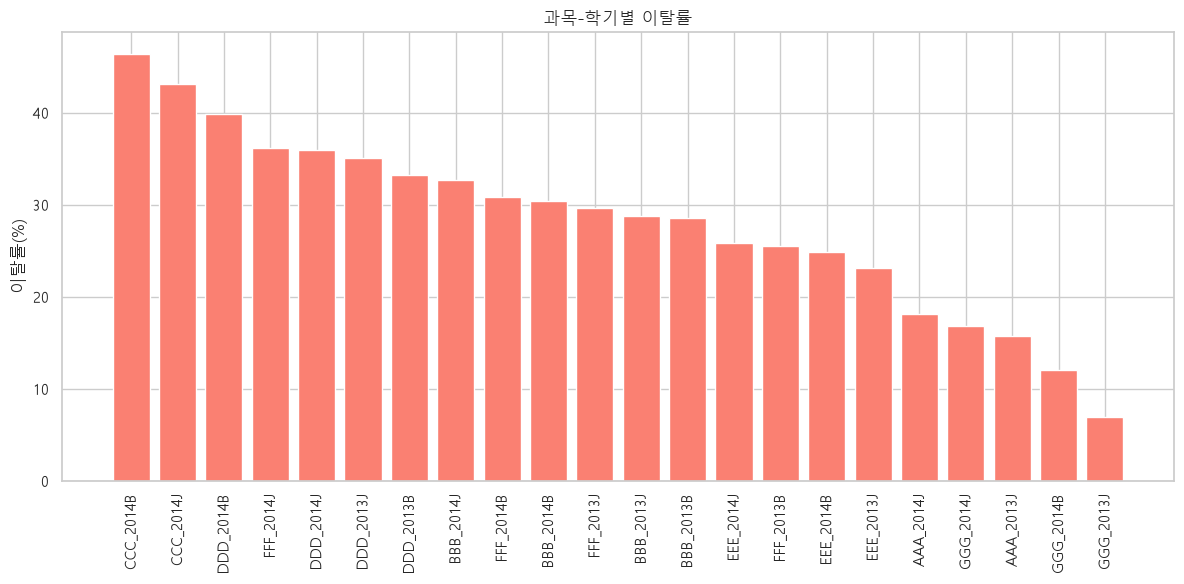

In [22]:
grp = info.groupby(["code_module", "code_presentation"]).agg(
    n_student=("id_student", "size"),
    n_withdrawn=("label_churn", lambda x: (x == "이탈").sum()),
).reset_index()
grp["이탈률(%)"] = (grp["n_withdrawn"] / grp["n_student"] * 100).round(1)
grp = pd.merge(grp, courses, on=["code_module", "code_presentation"], how="left")

print("과목-학기별 이탈률 (학생수 내림차순):")
print(grp.sort_values("n_student", ascending=False).to_string(index=False))

plt.figure(figsize=(12, 6))
grp_sorted = grp.sort_values("이탈률(%)", ascending=False)
labels = grp_sorted["code_module"] + "_" + grp_sorted["code_presentation"]
plt.bar(labels, grp_sorted["이탈률(%)"], color="salmon")
plt.xticks(rotation=90)
plt.ylabel("이탈률(%)")
plt.title("과목-학기별 이탈률")
plt.tight_layout()
plt.show()

**[확인 결과]** 과목-학기별 이탈률은 최저 6.9%(GGG_2013J)부터 최고 46.4%(CCC_2014B)까지
**최대 7배 가까이 차이**가 납니다. 같은 과목(GGG, CCC 등) 안에서도 학기(presentation)에 따라
편차가 있지만, 대체로 같은 과목끼리는 비슷한 수준에 모여 있는 경향이 보입니다(예: GGG 계열은
전부 6.9~16.8%로 낮은 편, CCC 계열은 43.1%·46.4%로 항상 높은 편). 즉 학기보다는 **과목
자체의 특성**이 이탈률을 가르는 더 큰 요인으로 보입니다. 다음 단계에서 과목(code_module)
단위로 통합해 이를 확인합니다.

# 5. 과목(code_module)별 통합 이탈률 — 핵심 발견

학기 구분 없이 과목 단위로 전체 학생을 통합해서 이탈률을 비교합니다.

             n_student  n_withdrawn  이탈률(%)
code_module                                
CCC               4434         1975    44.5
DDD               6272         2250    35.9
FFF               7762         2403    31.0
BBB               7909         2388    30.2
EEE               2934          722    24.6
AAA                748          126    16.8
GGG               2534          292    11.5


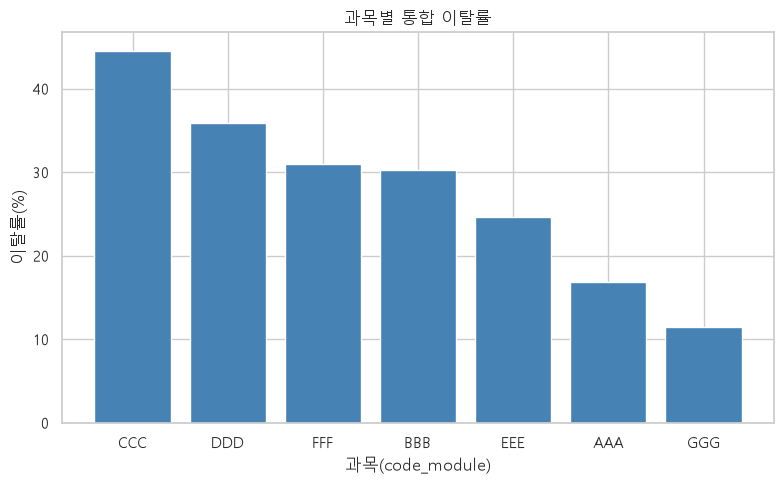

In [23]:
mod_grp = info.groupby("code_module").agg(
    n_student=("id_student", "size"),
    n_withdrawn=("label_churn", lambda x: (x == "이탈").sum()),
)
mod_grp["이탈률(%)"] = (mod_grp["n_withdrawn"] / mod_grp["n_student"] * 100).round(1)
mod_grp = mod_grp.sort_values("이탈률(%)", ascending=False)
print(mod_grp)

plt.figure(figsize=(8, 5))
plt.bar(mod_grp.index, mod_grp["이탈률(%)"], color="steelblue")
plt.ylabel("이탈률(%)")
plt.xlabel("과목(code_module)")
plt.title("과목별 통합 이탈률")
plt.tight_layout()
plt.show()

**[확인 결과 — 가장 중요한 발견]** 과목 단위로 통합해도 격차가 그대로 유지됩니다. **CCC가
44.5%로 가장 높고, GGG가 11.5%로 가장 낮습니다** — 약 3.9배 차이입니다. 전체 순위는
CCC(44.5%) > DDD(35.9%) > FFF(31.0%) > BBB(30.2%) > EEE(24.6%) > AAA(16.8%) > GGG(11.5%)
순입니다.

**[의미]** 같은 학교, 같은 온라인 학습 시스템 안에서도 **과목 자체의 성격(난이도, 분야, 설계
방식 등)에 따라 이탈률이 최대 4배 가까이 벌어질 수 있다**는 뜻입니다. 이는 04번에서 본
참여도 차이나 03번에서 본 과제 제출률 차이 못지않게, 어쩌면 그보다 먼저 살펴봐야 할 요인일
수 있습니다.

# 6. 이탈률에 영향을 주는 다른 요인 확인 — 학기 길이 · 개강 시즌

과목 자체의 특성 외에, 학기 길이(module_presentation_length)나 개강 시즌(2월 시작 B / 10월
시작 J)처럼 운영상의 요인도 이탈률에 영향을 주는지 확인합니다.

module_presentation_length와 이탈률(%)의 상관계수: -0.171


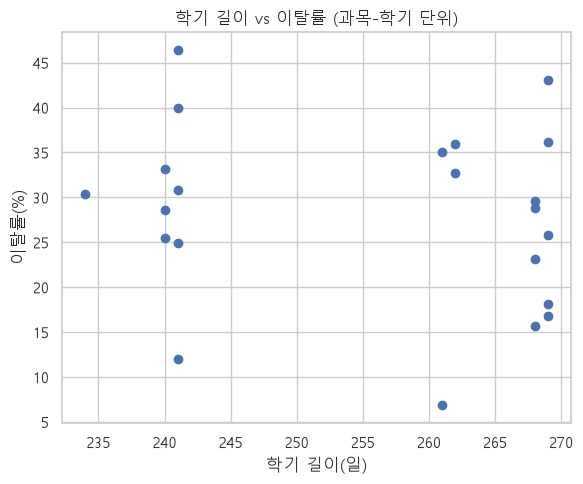


[개강 시즌별 이탈률] (B=2월 시작, J=10월 시작)
      학생수합계   이탈수합계  이탈률(%)
시즌                         
B   12488.0  3961.0    31.7
J   20105.0  6195.0    30.8


In [24]:
# 6-1. 학기 길이와 이탈률의 상관관계
corr = grp[["module_presentation_length", "이탈률(%)"]].corr().iloc[0, 1]
print("module_presentation_length와 이탈률(%)의 상관계수:", round(corr, 3))

plt.figure(figsize=(6, 5))
plt.scatter(grp["module_presentation_length"], grp["이탈률(%)"])
plt.xlabel("학기 길이(일)")
plt.ylabel("이탈률(%)")
plt.title("학기 길이 vs 이탈률 (과목-학기 단위)")
plt.tight_layout()
plt.show()

# 6-2. 개강 시즌(B/J)별 이탈률
grp["시즌"] = grp["code_presentation"].str[-1]
season_grp = grp.groupby("시즌").apply(
    lambda g: pd.Series({
        "학생수합계": g["n_student"].sum(),
        "이탈수합계": g["n_withdrawn"].sum(),
        "이탈률(%)": round(g["n_withdrawn"].sum() / g["n_student"].sum() * 100, 1),
    }),
    include_groups=False,
)
print("\n[개강 시즌별 이탈률] (B=2월 시작, J=10월 시작)")
print(season_grp)

**[확인 결과]** 학기 길이와 이탈률의 상관계수는 **-0.17**로 사실상 관계가 거의 없습니다(학기가
조금 길다고 이탈률이 뚜렷이 낮아지거나 하지 않음). 개강 시즌도 B(2월 시작) 31.7% vs J(10월
시작) 30.8%로 **1%p 이내 차이**라 의미 있는 차이로 보기 어렵습니다.

**[의미]** 앞서 5번에서 본 "과목별 최대 4배 차이"에 비하면, 학기 길이나 개강 시즌 같은 운영상
요인은 이탈률에 거의 영향을 주지 않습니다. 즉 이탈 위험은 **"언제 개강했는지"보다 "어떤
과목인지"에 훨씬 크게 좌우**됩니다.

# 7. 종합 정리 및 고용노동부 훈련과정 적용 시사점

**[핵심 발견]**
1. 과목-학기 단위 이탈률은 6.9%~46.4%까지 폭넓게 분포(최대 7배 차이).
2. 학기 구분 없이 과목(code_module) 단위로 봐도 격차가 그대로 유지됨(11.5%~44.5%, 최대
   3.9배) — 즉 **학기 편차가 아니라 과목 자체의 구조적 차이**.
3. 학기 길이(상관계수 -0.17)와 개강 시즌(B 31.7% vs J 30.8%)은 이탈률에 거의 영향을 주지
   않음 — 운영상 요인보다 **과목 정체성(분야·난이도·설계)** 이 훨씬 강력한 요인.

**[고용노동부 훈련과정 적용 시사점]**
- 조기경보 모델이나 이탈 방지 정책을 **전체 훈련과정에 동일한 기준으로 일괄 적용하면 안
  됩니다.** 과정(과목)마다 기본 이탈률 자체가 크게 다르므로(GGG형 11.5% vs CCC형 44.5%),
  같은 "위험도 점수"라도 과정에 따라 실제 의미가 달라질 수 있습니다.
- 03번(과제 제출률), 04번(VLE 참여도)에서 만든 조기경보 지표는 **과목/과정별로 기준선을
  따로 두거나, 최소한 과목(과정) 코드를 예측 모델의 피처로 포함**시키는 것이 바람직합니다.
- 반대로 개강 시기(계절학기 여부 등)는 이탈률과 거의 무관했으므로, "언제 개강했는가"보다는
  "어떤 과정인가"에 우선 자원을 집중해 원인(교육과정 설계, 난이도, 분야 특성 등)을 들여다볼
  필요가 있습니다.

# 8. 재검증 — 과목별 이탈률 차이가 인구통계 구성 차이로 설명되는지 확인

5번에서 "과목 자체의 특성"이 이탈률을 가르는 핵심 요인이라고 결론 내렸는데, 이 결론을 받아들이기
전에 짚어야 할 게 있습니다. 01번 노트북에서 이미 성별·연령대·장애 여부·이전 응시 횟수 같은
인구통계 변수가 이탈률과 관련 있다는 걸 확인했었습니다. 만약 특정 과목에 특정 인구통계 집단이
쏠려 있다면, 5번에서 본 "과목 격차"는 사실 과목 자체의 설계 문제가 아니라 **"어떤 학생들이
그 과목을 듣는지"의 차이일 수도 있습니다.** 과목별 인구통계 구성을 직접 확인해서 이 가능성을
검증합니다.

In [25]:
demo = mod_grp.copy()
demo["여성비율(%)"] = info.groupby("code_module")["gender"].apply(lambda x: (x == "F").mean() * 100).round(1)
demo["장애비율(%)"] = info.groupby("code_module")["disability"].apply(lambda x: (x == "Y").mean() * 100).round(1)
demo["연령0_35비율(%)"] = info.groupby("code_module")["age_band"].apply(lambda x: (x == "0-35").mean() * 100).round(1)
demo["평균이전응시횟수"] = info.groupby("code_module")["num_of_prev_attempts"].mean().round(2)
demo["최극빈층비율(%)"] = info.groupby("code_module")["imd_band"].apply(lambda x: (x == "0-10%").mean() * 100).round(1)

print("[과목별 인구통계 구성 및 이탈률]")
print(demo[["이탈률(%)", "여성비율(%)", "장애비율(%)", "연령0_35비율(%)", "평균이전응시횟수", "최극빈층비율(%)"]])

print("\n[이탈률과 인구통계 지표 간 상관계수 - 과목 7개 기준, 참고용]")
print(demo[["이탈률(%)", "여성비율(%)", "장애비율(%)", "연령0_35비율(%)", "평균이전응시횟수", "최극빈층비율(%)"]].corr()["이탈률(%)"].round(2))

[과목별 인구통계 구성 및 이탈률]
             이탈률(%)  여성비율(%)  장애비율(%)  연령0_35비율(%)  평균이전응시횟수  최극빈층비율(%)
code_module                                                            
CCC            44.5     24.8      8.6         70.7      0.05        8.5
DDD            35.9     40.1     11.8         74.3      0.25        8.8
FFF            31.0     18.2      9.5         74.0      0.20       10.3
BBB            30.2     88.4      9.4         66.8      0.21       13.1
EEE            24.6     11.5      5.7         75.8      0.05        7.2
AAA            16.8     42.0      5.6         47.1      0.05        4.0
GGG            11.5     80.6     14.0         61.0      0.03       11.9

[이탈률과 인구통계 지표 간 상관계수 - 과목 7개 기준, 참고용]
이탈률(%)         1.00
여성비율(%)       -0.39
장애비율(%)       -0.07
연령0_35비율(%)    0.63
평균이전응시횟수       0.44
최극빈층비율(%)      0.09
Name: 이탈률(%), dtype: float64


**[확인 결과]** 과목별 인구통계 구성은 실제로 크게 다릅니다. 성별은 EEE(여성 11.5%)부터
GGG(여성 80.6%)까지, 연령대(0-35세 비율)는 AAA(47.1%)부터 EEE(75.8%)까지 넓게 갈립니다.
과목(7개) 단위 상관계수를 참고로 보면 **연령0-35 비율(+0.63)** 과 **평균 이전 응시
횟수(+0.44)** 가 이탈률과 같은 방향으로 움직여서, 01번에서 이미 확인한 "젊은 층·재수강
경험자일수록 이탈 위험이 높다"는 패턴과 일관됩니다. 즉 **과목별 이탈률 차이의 일부는 실제로
"어떤 학생이 그 과목을 듣는가"라는 인구통계 구성 차이로 설명됩니다.**

다만 표본이 과목 7개뿐이라 상관계수 자체는 참고용으로만 봐야 하고, 인구통계만으로 전부
설명되지도 않습니다. 예를 들어 **GGG는 장애 학생 비율이 14.0%로 7개 과목 중 가장 높은데도
이탈률은 가장 낮습니다(11.5%)** — 장애 여부가 이탈 위험 요인이라는 01번의 결론과 반대
방향입니다. 반대로 **CCC는 여성 비율(24.8%)·최극빈층 비율(8.5%)이 특별히 나쁜 편이 아닌데도
이탈률이 가장 높습니다(44.5%)**. 인구통계만으로는 두 극단값(GGG의 최저치, CCC의 최고치) 모두
설명이 잘 안 됩니다.

**[결론 — 5번 결론 보완]** 과목별 이탈률 격차는 **인구통계 구성 차이(자기선택 효과)와 과목
자체의 특성(난이도·설계·분야)이 함께 작용한 결과**로 보는 것이 더 정확합니다. 5번에서 "과목
자체의 특성"이라고 단정한 것은 다소 성급했고, 실제로는 두 요인이 섞여 있습니다.

**[고용노동부 훈련과정 적용 시사점 — 보완]** 과정별 기준선을 따로 두자는 7번의 제안은 여전히
유효하지만, 그 이유를 더 정확히 말하면 "이 과정이 원래 어렵거나 잘 설계되지 않아서"가 아니라
**"이 과정에 어떤 특성의 학생들이 모이는지"까지 함께 봐야 한다는 뜻**입니다. 실제 정책 설계
시에는 과정 코드 하나만 피처로 넣기보다, 인구통계 변수(연령·이전 수강 이력 등)와 과정 코드를
함께 고려해야 두 효과를 구분하고 각각에 맞는 대응(교육과정 개선 vs 특정 학생군 지원)을 할 수
있습니다.